# Qwen3-4B-MegaScience fine tuning on GSM8K

Qwen3-4B-MegaScience is a scientific SLM. We fine tune it on GSM8K with LoRA. The answer format is rewritten into `<think>` and `<answer>`.

## Setup

The stack below covers training, Hub upload, plotting, and GPU telemetry.

In [ ]:
!pip install -U "transformers>=4.52.0" accelerate peft trl datasets huggingface_hub pandas matplotlib nvidia-ml-py tensorboard sentencepiece protobuf safetensors

## Imports and configuration

Our setup includes RTX 5090 with cuda 13.0, Ryzen 9 9950X, 62 GB RAM.

In [15]:
import os
import re
import json
import time
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pynvml
from tqdm import tqdm

from datasets import load_dataset
from huggingface_hub import HfApi, login, upload_folder
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainerCallback
from trl import SFTConfig, SFTTrainer

os.environ["TOKENIZERS_PARALLELISM"] = "false"

seed = 3407
base_model_id = "MegaScience/Qwen3-4B-MegaScience"
hub_model_id = "pymlex/qwen3-4b-gsm8k"
run_dir = Path("./qwen3_gsm8k_run")
adapter_dir = run_dir / "adapter"
publish_dir = run_dir / "publish"
run_dir.mkdir(parents=True, exist_ok=True)
adapter_dir.mkdir(parents=True, exist_ok=True)
publish_dir.mkdir(parents=True, exist_ok=True)

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
fp16 = torch.cuda.is_available() and not bf16

pynvml.nvmlInit()

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
device_props = torch.cuda.get_device_properties(0) if torch.cuda.is_available() else None
vram_gb = device_props.total_memory / (1024 ** 3) if device_props is not None else 0.0

print(f"GPU: {device_name}")
print(f"VRAM: {vram_gb:.2f} GB")
print(f"bf16: {bf16}")
print(f"fp16: {fp16}")

GPU: NVIDIA GeForce RTX 5090
VRAM: 31.36 GB
bf16: True
fp16: False


## Dataset

GSM8K already ships with calculation annotations inside `answer`. The final scalar answer sits after `####`, and that piece is moved into the `<answer>` block during formatting. The official train split is used for training and validation.

In [4]:
raw = load_dataset("openai/gsm8k", "main")

train_full = raw["train"].shuffle(seed=seed)
test_ds = raw["test"]

split = train_full.train_test_split(test_size=0.05, seed=seed)
train_base = split["train"]
val_base = split["test"]

print(train_base)
print(val_base)
print(test_ds)
print(train_base[0]["question"])
print(train_base[0]["answer"][:400])

Dataset({
    features: ['question', 'answer'],
    num_rows: 7099
})
Dataset({
    features: ['question', 'answer'],
    num_rows: 374
})
Dataset({
    features: ['question', 'answer'],
    num_rows: 1319
})
Emma is 7 years old.  If her sister is 9 years older than her, how old will Emma be when her sister is 56?
Emma’s sister is 7 + 9 = <<7+9=16>>16 years old.
In this many years, Emma’s sister will be 56 years old: 56 - 16 = <<56-16=40>>40 years.
When her sister is 56 years old, Emma will be 7 + 40 = <<7+40=47>>47 years.
#### 47


## Chat format

The target answer keeps the calculation trace in `<think>` and places the final value in `<answer>`.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if bf16 else torch.float16,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
    attn_implementation="sdpa",
)

special_tokens = {
    "additional_special_tokens": ["<think>", "</think>", "<answer>", "</answer>"]
}
added = tokenizer.add_special_tokens(special_tokens)
if added > 0:
    model.resize_token_embeddings(len(tokenizer))

model.config.use_cache = False
model.generation_config.pad_token_id = tokenizer.pad_token_id

SYSTEM_PROMPT = (
    "You solve grade-school math problems. "
    "Put the reasoning in <think>...</think>. "
    "Put only the final result as a single number in <answer>...</answer>."
)

answer_re = re.compile(r"####\s*(.*)$", re.S)

def canonicalize_answer(text):
    s = str(text).strip().replace(",", "").replace("$", "")
    s = s.replace(" ", "")
    if s.endswith(".0"):
        s = s[:-2]
    if s.endswith("."):
        s = s[:-1]
    return s

def split_reasoning_and_answer(answer_text):
    match = answer_re.search(answer_text)
    if match is None:
        return answer_text.strip(), ""
    reasoning = answer_text[:match.start()].strip()
    final_answer = canonicalize_answer(match.group(1))
    return reasoning, final_answer

def build_text(example):
    reasoning, final_answer = split_reasoning_and_answer(example["answer"])
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": example["question"].strip()},
        {
            "role": "assistant",
            "content": f"<think>\n{reasoning}\n</think>\n<answer>\n{final_answer}\n</answer>"
        },
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    if not text.endswith(tokenizer.eos_token):
        text += tokenizer.eos_token
    token_count = len(tokenizer(text, add_special_tokens=False)["input_ids"])
    return {
        "text": text,
        "n_tokens": token_count,
        "final_answer": final_answer,
    }

train_ds = train_base.map(build_text, remove_columns=train_base.column_names)
val_ds = val_base.map(build_text, remove_columns=val_base.column_names)
test_formatted = test_ds.map(build_text, remove_columns=test_ds.column_names)

eval_subset = val_base.select(range(min(100, len(val_base))))

print(train_ds[0]["text"][:1200])
print(len(train_ds), len(val_ds), len(test_formatted))

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

<|im_start|>system
You solve grade-school math problems. Put the reasoning in <think>...</think>. Put only the final result as a single number in <answer>...</answer>.<|im_end|>
<|im_start|>user
Emma is 7 years old.  If her sister is 9 years older than her, how old will Emma be when her sister is 56?<|im_end|>
<|im_start|>assistant
<think>
Emma’s sister is 7 + 9 = <<7+9=16>>16 years old.
In this many years, Emma’s sister will be 56 years old: 56 - 16 = <<56-16=40>>40 years.
When her sister is 56 years old, Emma will be 7 + 40 = <<7+40=47>>47 years.
</think>

<answer>
47
</answer><|im_end|>
<|im_end|>
7099 374 1319


## Token lengths

We will set the maximum sequence lenght to 768 to make the model process texts in all the expected scenarios.

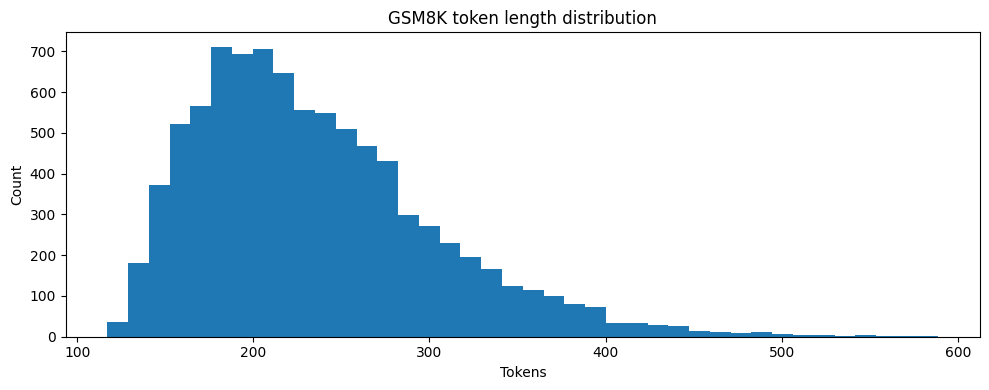

In [7]:
all_tokens = list(train_ds["n_tokens"]) + list(val_ds["n_tokens"]) + list(test_formatted["n_tokens"])

plt.figure(figsize=(10, 4))
plt.hist(all_tokens, bins=40)
plt.title("GSM8K token length distribution")
plt.xlabel("Tokens")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(run_dir / "token_lengths.png", dpi=160)
plt.show()

## Evaluation helpers

Exact match is computed from the final value inside `<answer>`. If the tag is missing, the code falls back to the last number in the completion.

In [16]:
number_re = re.compile(r"-?\d+(?:,\d{3})*(?:\.\d+)?")
answer_block_re = re.compile(r"<answer>\s*(.*?)\s*</answer>", re.S)

def extract_gold_answer(text):
    match = answer_re.search(text)
    if match is not None:
        return canonicalize_answer(match.group(1))
    nums = number_re.findall(text.replace(",", ""))
    if nums:
        return canonicalize_answer(nums[-1])
    return canonicalize_answer(text)

def extract_pred_answer(text):
    match = answer_block_re.search(text)
    if match is not None:
        return canonicalize_answer(match.group(1))
    match = answer_re.search(text)
    if match is not None:
        return canonicalize_answer(match.group(1))
    nums = number_re.findall(text.replace(",", ""))
    if nums:
        return canonicalize_answer(nums[-1])
    return canonicalize_answer(text)

def build_prompt(question):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question.strip()},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

def generate_batch(model, tokenizer, prompts, max_new_tokens=256):
    device = next(model.parameters()).device
    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=False)
    return decoded

def evaluate_exact_match(model, tokenizer, dataset, n_examples=None, batch_size=4, max_new_tokens=512):
    limit = len(dataset) if n_examples is None else min(len(dataset), n_examples)
    subset = dataset.select(range(limit))
    rows = []
    correct = 0

    for start in tqdm(range(0, limit, batch_size)):
        batch = subset[start:start + batch_size]
        prompts = [build_prompt(q) for q in batch["question"]]
        decoded = generate_batch(model, tokenizer, prompts, max_new_tokens=max_new_tokens)

        for question, gold_text, prompt, full_text in zip(batch["question"], batch["answer"], prompts, decoded):
            pred_text = full_text[len(prompt):] if full_text.startswith(prompt) else full_text
            pred = extract_pred_answer(pred_text)
            gold = extract_gold_answer(gold_text)
            is_correct = int(pred == gold)
            correct += is_correct
            rows.append(
                {
                    "question": question,
                    "gold_answer": gold,
                    "pred_answer": pred,
                    "correct": is_correct,
                    "pred_text": pred_text,
                }
            )

    df = pd.DataFrame(rows)
    return df, correct / limit

    df = pd.DataFrame(rows)
    return df, correct / limit

## GPU logging

In [9]:
gpu_history = []

class TrainStatusCallback(TrainerCallback):
    def __init__(self, eval_subset):
        self.eval_subset = eval_subset
        self.trainer = None

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        row = {
            "step": int(state.global_step),
            "epoch": float(state.epoch) if state.epoch is not None else np.nan,
            "time": time.time(),
        }
        for key in ["loss", "eval_loss", "learning_rate", "grad_norm"]:
            if key in logs:
                row[key] = float(logs[key])
        if torch.cuda.is_available():
            handle = pynvml.nvmlDeviceGetHandleByIndex(torch.cuda.current_device())
            util = pynvml.nvmlDeviceGetUtilizationRates(handle)
            mem = pynvml.nvmlDeviceGetMemoryInfo(handle)
            row["gpu_util"] = float(util.gpu)
            row["mem_used_mb"] = float(mem.used / (1024 ** 2))
            row["mem_total_mb"] = float(mem.total / (1024 ** 2))
            msg = f"[step {state.global_step}] "
            if "loss" in logs:
                msg += f"loss={logs['loss']:.4f} "
            if "eval_loss" in logs:
                msg += f"eval_loss={logs['eval_loss']:.4f} "
            msg += f"GPU={util.gpu}% VRAM={mem.used/1024**2:.0f}/{mem.total/1024**2:.0f} MB"
            print(msg)
        gpu_history.append(row)

    def on_evaluate(self, args, state, control, **kwargs):
        if self.trainer is None or self.eval_subset is None:
            return
        metrics_df, acc = evaluate_exact_match(
            self.trainer.model,
            self.trainer.processing_class,
            self.eval_subset,
            n_examples=100,
            batch_size=4,
            max_new_tokens=256,
        )
        metrics = {
            "eval_exact_match_100": acc,
            "eval_correct_100": int(metrics_df["correct"].sum()),
            "eval_total_100": int(len(metrics_df)),
        }
        self.trainer.log(metrics)
        payload = dict(metrics)
        payload["step"] = int(state.global_step)
        payload["epoch"] = float(state.epoch) if state.epoch is not None else np.nan
        payload["time"] = time.time()
        gpu_history.append(payload)
        print(f"[step {state.global_step}] eval_exact_match_100={acc:.4f}")

## Trainer

In [10]:
eval_subset = val_base.select(range(min(100, len(val_base))))

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

training_args = SFTConfig(
    output_dir=str(adapter_dir),
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    warmup_steps=20,
    lr_scheduler_type="cosine",
    weight_decay=0.0,
    optim="adamw_torch",
    logging_strategy="steps",
    logging_steps=1,
    eval_strategy="steps",
    eval_steps=25,
    eval_on_start=True,
    save_strategy="steps",
    save_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=bf16,
    fp16=fp16,
    gradient_checkpointing=True,
    report_to="tensorboard",
    seed=seed,
    packing=False,
    dataset_text_field="text",
    max_length=768,
    logging_first_step=True,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    peft_config=lora_config,
    processing_class=tokenizer,
)

status_cb = TrainStatusCallback(eval_subset)
status_cb.trainer = trainer
trainer.add_callback(status_cb)

print("trainer ready")

trainer ready


## Training

In [11]:
train_result = trainer.train()
print(train_result)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
0,No log,2.089016
25,0.408335,0.418331
50,0.368056,0.366697
75,0.343977,0.356384
100,0.366282,0.350802
125,0.339358,0.348205
150,0.390431,0.346121
175,0.346124,0.344797
200,0.352397,0.344206
222,0.369009,0.344098


[step 0] eval_loss=2.0890 GPU=95% VRAM=16318/32607 MB
[step 0] GPU=78% VRAM=16332/32607 MB
[step 0] eval_exact_match_100=0.2200
[step 1] loss=2.1023 GPU=88% VRAM=16778/32607 MB
[step 2] loss=2.2198 GPU=87% VRAM=17670/32607 MB
[step 3] loss=2.1929 GPU=91% VRAM=17670/32607 MB
[step 4] loss=2.1926 GPU=71% VRAM=18656/32607 MB
[step 5] loss=2.0107 GPU=97% VRAM=18656/32607 MB
[step 6] loss=1.8966 GPU=96% VRAM=18656/32607 MB
[step 7] loss=1.8916 GPU=95% VRAM=18656/32607 MB
[step 8] loss=1.7318 GPU=90% VRAM=18656/32607 MB
[step 9] loss=1.5379 GPU=88% VRAM=18656/32607 MB
[step 10] loss=1.2925 GPU=97% VRAM=19818/32607 MB
[step 11] loss=1.2532 GPU=94% VRAM=19818/32607 MB
[step 12] loss=1.0723 GPU=90% VRAM=19818/32607 MB
[step 13] loss=0.9937 GPU=95% VRAM=19818/32607 MB
[step 14] loss=0.8682 GPU=95% VRAM=19818/32607 MB
[step 15] loss=0.7871 GPU=89% VRAM=19818/32607 MB
[step 16] loss=0.6485 GPU=97% VRAM=19818/32607 MB
[step 17] loss=0.5811 GPU=96% VRAM=19818/32607 MB
[step 18] loss=0.5456 GPU=94% V

/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


[step 51] loss=0.3877 GPU=94% VRAM=21048/32607 MB
[step 52] loss=0.3838 GPU=95% VRAM=21048/32607 MB
[step 53] loss=0.3443 GPU=96% VRAM=21048/32607 MB
[step 54] loss=0.3773 GPU=95% VRAM=21048/32607 MB
[step 55] loss=0.3573 GPU=96% VRAM=21048/32607 MB
[step 56] loss=0.3939 GPU=89% VRAM=21048/32607 MB
[step 57] loss=0.3672 GPU=95% VRAM=21048/32607 MB
[step 58] loss=0.3673 GPU=88% VRAM=21048/32607 MB
[step 59] loss=0.3506 GPU=96% VRAM=21048/32607 MB
[step 60] loss=0.4168 GPU=95% VRAM=21048/32607 MB
[step 61] loss=0.3795 GPU=95% VRAM=21048/32607 MB
[step 62] loss=0.3852 GPU=95% VRAM=21048/32607 MB
[step 63] loss=0.3734 GPU=96% VRAM=21048/32607 MB
[step 64] loss=0.3649 GPU=90% VRAM=21048/32607 MB
[step 65] loss=0.3797 GPU=96% VRAM=21048/32607 MB
[step 66] loss=0.3820 GPU=88% VRAM=21048/32607 MB
[step 67] loss=0.3699 GPU=96% VRAM=21048/32607 MB
[step 68] loss=0.3923 GPU=29% VRAM=21048/32607 MB
[step 69] loss=0.3930 GPU=95% VRAM=21048/32607 MB
[step 70] loss=0.3757 GPU=97% VRAM=21048/32607 MB


...

[step 151] loss=0.3328 GPU=91% VRAM=27864/32607 MB
[step 152] loss=0.3426 GPU=96% VRAM=27864/32607 MB
[step 153] loss=0.3485 GPU=96% VRAM=27864/32607 MB
[step 154] loss=0.3344 GPU=87% VRAM=27864/32607 MB
[step 155] loss=0.3581 GPU=95% VRAM=27864/32607 MB
[step 156] loss=0.3511 GPU=96% VRAM=27864/32607 MB
[step 157] loss=0.3593 GPU=94% VRAM=27864/32607 MB
[step 158] loss=0.3500 GPU=89% VRAM=27864/32607 MB
[step 159] loss=0.3475 GPU=96% VRAM=27864/32607 MB
[step 160] loss=0.3545 GPU=95% VRAM=27864/32607 MB
[step 161] loss=0.3571 GPU=96% VRAM=27864/32607 MB
[step 162] loss=0.3605 GPU=94% VRAM=27864/32607 MB
[step 163] loss=0.3626 GPU=96% VRAM=27864/32607 MB
[step 164] loss=0.3316 GPU=96% VRAM=27864/32607 MB
[step 165] loss=0.3422 GPU=90% VRAM=27864/32607 MB
[step 166] loss=0.3302 GPU=96% VRAM=27864/32607 MB
[step 167] loss=0.3241 GPU=86% VRAM=27864/32607 MB
[step 168] loss=0.3446 GPU=95% VRAM=27864/32607 MB
[step 169] loss=0.3398 GPU=89% VRAM=27864/32607 MB
[step 170] loss=0.3516 GPU=89% 

/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1419: UserWarning: Unable to fetch remote file due to the following error [Errno 97] Address family not supported by protocol - silently ignoring the lookup for the file config.json in MegaScience/Qwen3-4B-MegaScience.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in MegaScience/Qwen3-4B-MegaScience - will assume that the vocabulary was not modified.
  warnings.warn(


[step 201] loss=0.3513 GPU=97% VRAM=27864/32607 MB
[step 202] loss=0.3486 GPU=95% VRAM=27864/32607 MB
[step 203] loss=0.3507 GPU=95% VRAM=27864/32607 MB
[step 204] loss=0.3456 GPU=97% VRAM=27864/32607 MB
[step 205] loss=0.3612 GPU=96% VRAM=27864/32607 MB
[step 206] loss=0.3479 GPU=97% VRAM=27864/32607 MB
[step 207] loss=0.3522 GPU=95% VRAM=27864/32607 MB
[step 208] loss=0.3537 GPU=86% VRAM=27864/32607 MB
[step 209] loss=0.3729 GPU=95% VRAM=27864/32607 MB
[step 210] loss=0.3466 GPU=96% VRAM=27864/32607 MB
[step 211] loss=0.3283 GPU=96% VRAM=27864/32607 MB
[step 212] loss=0.3392 GPU=89% VRAM=27864/32607 MB
[step 213] loss=0.3619 GPU=97% VRAM=27864/32607 MB
[step 214] loss=0.3700 GPU=87% VRAM=27864/32607 MB
[step 215] loss=0.3551 GPU=95% VRAM=27864/32607 MB
[step 216] loss=0.3346 GPU=94% VRAM=27864/32607 MB
[step 217] loss=0.3286 GPU=95% VRAM=27864/32607 MB
[step 218] loss=0.3198 GPU=96% VRAM=27864/32607 MB
[step 219] loss=0.3513 GPU=89% VRAM=27864/32607 MB
[step 220] loss=0.3585 GPU=95% 

/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


[step 222] GPU=14% VRAM=27864/32607 MB
TrainOutput(global_step=222, training_loss=0.4492494880079149, metrics={'train_runtime': 1580.5321, 'train_samples_per_second': 4.492, 'train_steps_per_second': 0.14, 'total_flos': 4.806038094014976e+16, 'train_loss': 0.4492494880079149})


## Logs and plots

Loss converges within one epoch. Training doesn’t show any improvement in the accuracy metric, which demonstrates the inefficiency of training on task-solution pairs while trying to give the model common sense.

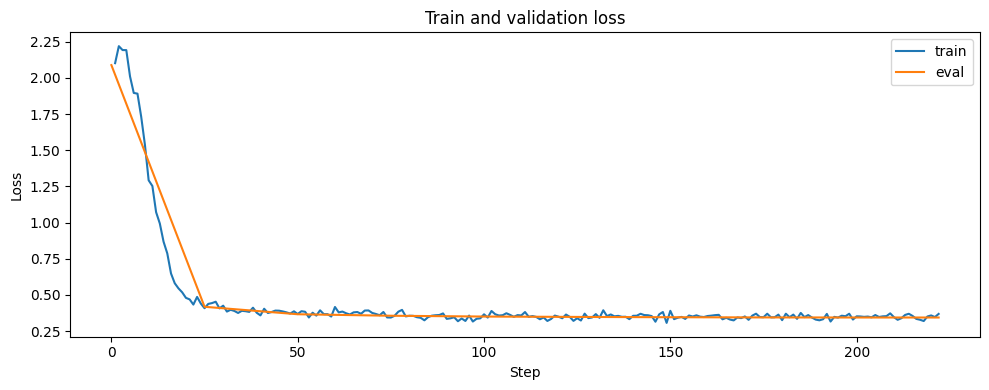

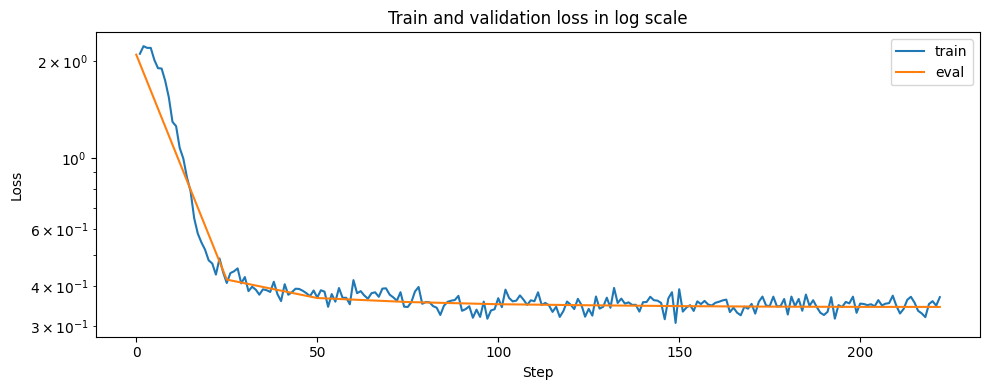

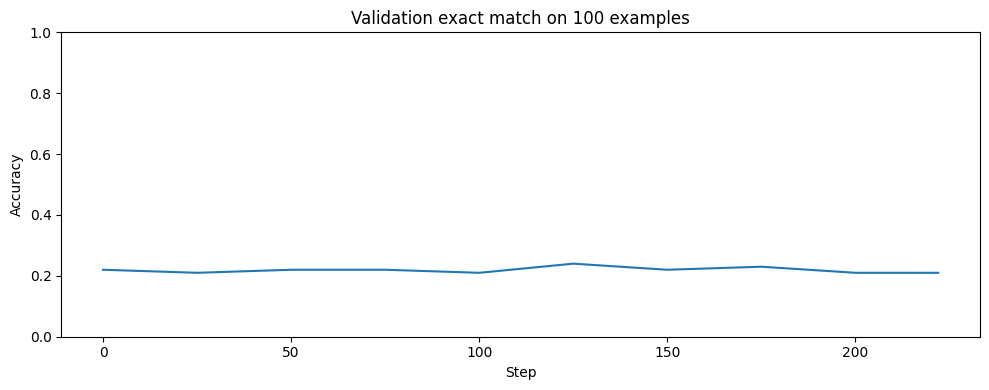

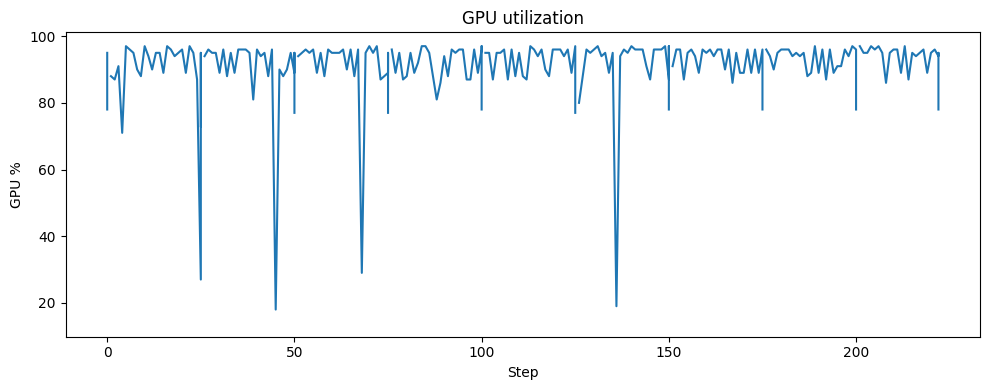

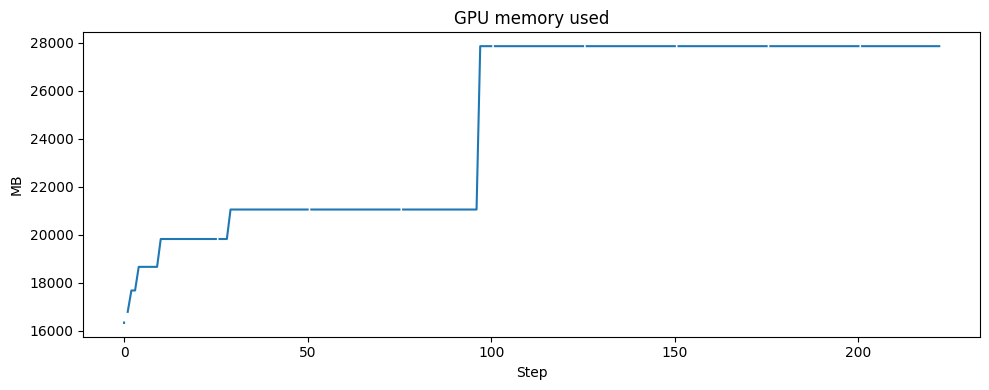

In [20]:
log_history = pd.DataFrame(trainer.state.log_history)
gpu_df = pd.DataFrame(gpu_history)

log_history.to_csv(run_dir / "trainer_log_history.csv", index=False)
gpu_df.to_csv(run_dir / "gpu_history.csv", index=False)

train_logs = log_history[log_history["loss"].notna()].copy()
eval_logs = log_history[log_history["eval_loss"].notna()].copy()

plt.figure(figsize=(10, 4))
if not train_logs.empty:
    plt.plot(train_logs["step"], train_logs["loss"])
if not eval_logs.empty:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"])
plt.title("Train and validation loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend(["train", "eval"])
plt.tight_layout()
plt.savefig(run_dir / "loss_curve.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 4))
if not train_logs.empty:
    plt.semilogy(train_logs["step"], train_logs["loss"])
if not eval_logs.empty:
    plt.semilogy(eval_logs["step"], eval_logs["eval_loss"])
plt.title("Train and validation loss in log scale")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend(["train", "eval"])
plt.tight_layout()
plt.savefig(run_dir / "loss_curve.png", dpi=160)
plt.show()

acc_logs = log_history[log_history.get("eval_exact_match_100", pd.Series(dtype=float)).notna()].copy()
if not acc_logs.empty:
    plt.figure(figsize=(10, 4))
    plt.plot(acc_logs["step"], acc_logs["eval_exact_match_100"])
    plt.title("Validation exact match on 100 examples")
    plt.xlabel("Step")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.tight_layout()
    plt.savefig(run_dir / "val_exact_match.png", dpi=160)
    plt.show()

if not gpu_df.empty and "gpu_util" in gpu_df.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(gpu_df["step"], gpu_df["gpu_util"])
    plt.title("GPU utilization")
    plt.xlabel("Step")
    plt.ylabel("GPU %")
    plt.tight_layout()
    plt.savefig(run_dir / "gpu_utilization.png", dpi=160)
    plt.show()

if not gpu_df.empty and "mem_used_mb" in gpu_df.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(gpu_df["step"], gpu_df["mem_used_mb"])
    plt.title("GPU memory used")
    plt.xlabel("Step")
    plt.ylabel("MB")
    plt.tight_layout()
    plt.savefig(run_dir / "gpu_memory_used.png", dpi=160)
    plt.show()

## Full test generation

100%|██████████| 165/165 [10:16<00:00,  3.73s/it]

test exact match: 0.0955


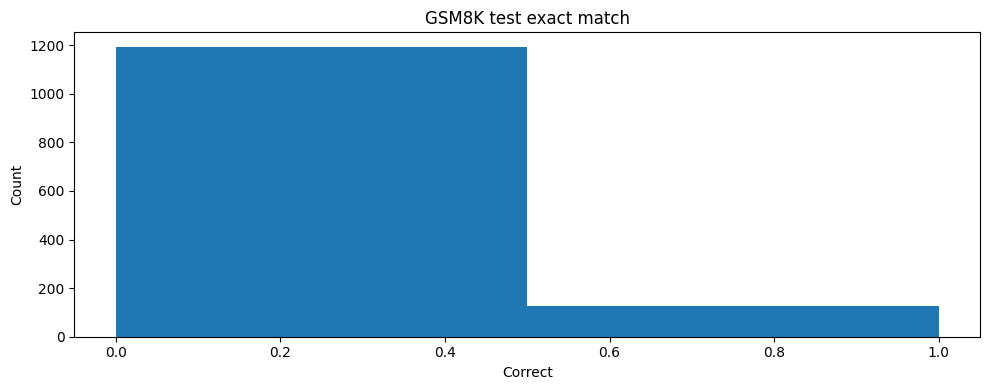

In [17]:
merged_model = trainer.model.merge_and_unload()
merged_model.eval()

test_eval_df, test_exact_match = evaluate_exact_match(
    merged_model,
    tokenizer,
    raw["test"],
    n_examples=None,
    batch_size=8,
    max_new_tokens=512,
)

print(f"test exact match: {test_exact_match:.4f}")
test_eval_df.to_csv(run_dir / "gsm8k_test_predictions.csv", index=False)

plt.figure(figsize=(10, 4))
plt.hist(test_eval_df["correct"].astype(int), bins=2)
plt.title("GSM8K test exact match")
plt.xlabel("Correct")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(run_dir / "test_exact_match_hist.png", dpi=160)
plt.show()

## Publish files

In [23]:
merged_model.save_pretrained(publish_dir, safe_serialization=True, max_shard_size="2GB")
tokenizer.save_pretrained(publish_dir)

val_acc_100 = np.nan
if "eval_exact_match_100" in log_history.columns:
    values = log_history["eval_exact_match_100"].dropna()
    if not values.empty:
        val_acc_100 = float(values.iloc[-1])

readme_text = f'''---
library_name: transformers
base_model: {base_model_id}
datasets:
  - openai/gsm8k
tags:
  - qwen3
  - gsm8k
  - lora
  - reasoning
  - math
  - benchmark
license: apache-2.0
---

# Qwen3-4B-MegaScience GSM8K fine-tune

## Overview

`MegaScience/Qwen3-4B-MegaScience` is a 4B Qwen3 modification trained on the MegaScience dataset. We fine-tuned it on GSM8K, which contains common-sense tasks for school students.

## Dataset

The official GSM8K train split is used for training and validation. We modify it by adding <think> and <answer> tokens so the model formats the answer more correctly.

## Training setup

Base model: `{base_model_id}`.  
Fine-tuning style: SFT with LoRA.  
Precision: {"bf16" if bf16 else "fp16"}.  
Max length: 768.  
Epochs: 1.  
Train / validation split: 95 / 5 from the official train split.

## Results

Validation loss: **0.3690**
Validation perplexity: **1.4463**
Test loss: **0.3441**
Test perplexity: **1.4107**
Test exact match: **0.0955**

## Inference

Use the same chat format as training. The answer goes inside `<answer>`.
'''
(publish_dir / "README.md").write_text(readme_text, encoding="utf-8")

eval_dir = publish_dir / ".eval_results"
eval_dir.mkdir(parents=True, exist_ok=True)
eval_yaml = f'''- dataset:
    id: openai/gsm8k
    task_id: gsm8k
    config: main
    split: test
  value: {test_exact_match:.6f}
  date: "{date.today().isoformat()}"
  notes: "greedy, no-tools, local eval"
'''
(eval_dir / "gsm8k.yaml").write_text(eval_yaml, encoding="utf-8")

training_meta = {
    "base_model_id": base_model_id,
    "hub_model_id": hub_model_id,
    "seed": seed,
    "bf16": bf16,
    "fp16": fp16,
}
(publish_dir / "training_meta.json").write_text(json.dumps(training_meta, indent=2, ensure_ascii=False), encoding="utf-8")

print(readme_text[:900])
print(eval_yaml)

Writing model shards:   0%|          | 0/5 [00:00<?, ?it/s]

---
library_name: transformers
base_model: MegaScience/Qwen3-4B-MegaScience
datasets:
  - openai/gsm8k
tags:
  - qwen3
  - gsm8k
  - lora
  - reasoning
  - math
  - benchmark
license: apache-2.0
---

# Qwen3-4B-MegaScience GSM8K fine-tune

## Overview

`MegaScience/Qwen3-4B-MegaScience` is a 4B Qwen3 modification trained on the MegaScience dataset. We fine-tuned it on GSM8K, which contains common-sense tasks for school students.

## Dataset

The official GSM8K train split is used for training and validation. We modify it by adding <think> and <answer> tokens so the model formats the answer more correctly.

## Training setup

Base model: `MegaScience/Qwen3-4B-MegaScience`.  
Fine-tuning style: SFT with LoRA.  
Precision: bf16.  
Max length: 768.  
Epochs: 1.  
Train / validation split: 95 / 5 from the official train split.

## Results

Validation loss: **0.3690**
Validation perplexity: **
- dataset:
    id: openai/gsm8k
    task_id: gsm8k
    config: main
    split: test
  value: 0.0955

## Hub upload

The token must already be available as `HF_TOKEN`. The folder upload keeps the merged model and the benchmark metadata together.

In [24]:
hf_token = "YOUR_TOKEN"
if hf_token is None or hf_token == "":
    login()
else:
    login(token=hf_token)

api = HfApi()
api.create_repo(hub_model_id, repo_type="model", exist_ok=True)

upload_folder(
    repo_id=hub_model_id,
    folder_path=str(publish_dir),
    repo_type="model",
    commit_message="Qwen3-4B-MegaScience fine-tuned on GSM8K",
)

print(hub_model_id)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

pymlex/qwen3-4b-gsm8k-think-answer


## Inference

In [26]:
def solve_question(model, tokenizer, question, max_new_tokens=512):
    prompt = build_prompt(question)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[-1]

    end_answer_id = tokenizer.convert_tokens_to_ids("</answer>")
    eos_id = tokenizer.eos_token_id

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=[eos_id, end_answer_id],
            pad_token_id=tokenizer.pad_token_id,
        )

    new_tokens = output[0][prompt_len:]
    text = tokenizer.decode(new_tokens, skip_special_tokens=False)

    if "</answer>" in text:
        text = text.split("</answer>")[0] + "</answer>"

    return text.strip()

sample_question = raw["test"][0]["question"]
sample_output = solve_question(merged_model, tokenizer, sample_question)
print(sample_question)
print(sample_output)

Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
<think>
She sells 16 - 3 - 4 = <<16-3-4=9>>9 eggs each day at the farmers' market.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmers' market.
</think>

<think>
18
<think><|im_end|>
